In [6]:
import numpy as np

# Set up matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as colors

%matplotlib inline

from astropy.io import fits

from astropy.utils.data import download_file

image_file = download_file(
    "https://things.cv.nrao.edu/littlethings/ngc2366/HI/NGC2366_R_X0_P_R.FITS", cache=True
)

hdu_list = fits.open(image_file)
hdu_list.info()

image_data = hdu_list[0].data

image_data_2d = np.squeeze(image_data)

Filename: C:\Users\HP\.astropy\cache\download\url\5c4c2abaefb079d370f9a22ef360e989\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     596   (1024, 1024, 1, 1)   float32   


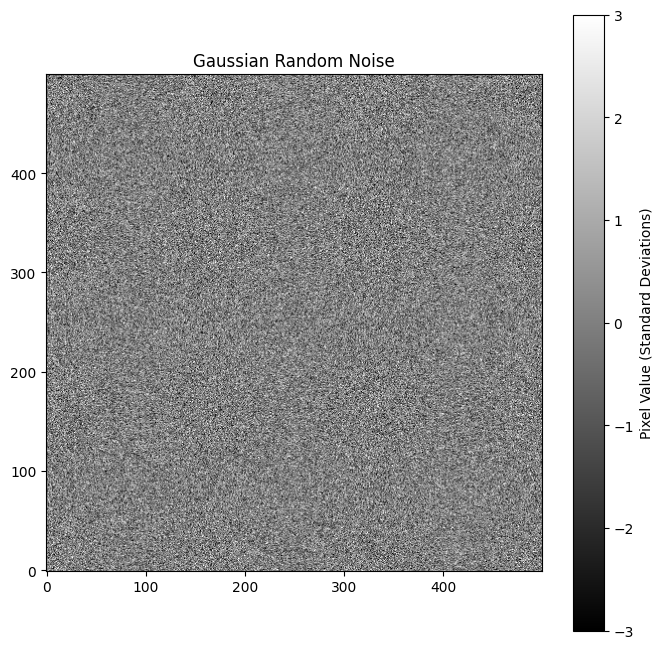

In [7]:
###########AI-Generated###############
height, width = 500, 500

# Set the parameters for the Gaussian curve
mean = 0.0      # The average pixel value
std_dev = 1.0   # How spread out the values are (standard deviation)

# np.random.normal creates the Gaussian noise array
gaussian_noise = np.random.normal(mean, std_dev, (height, width))

plt.figure(figsize=(8, 8))
# We use vmin and vmax to lock the contrast, otherwise outliers stretch the colormap too far
plt.imshow(gaussian_noise, cmap='gray', origin='lower', vmin=-3, vmax=3)
plt.colorbar(label='Pixel Value (Standard Deviations)')
plt.title('Gaussian Random Noise')
plt.show()

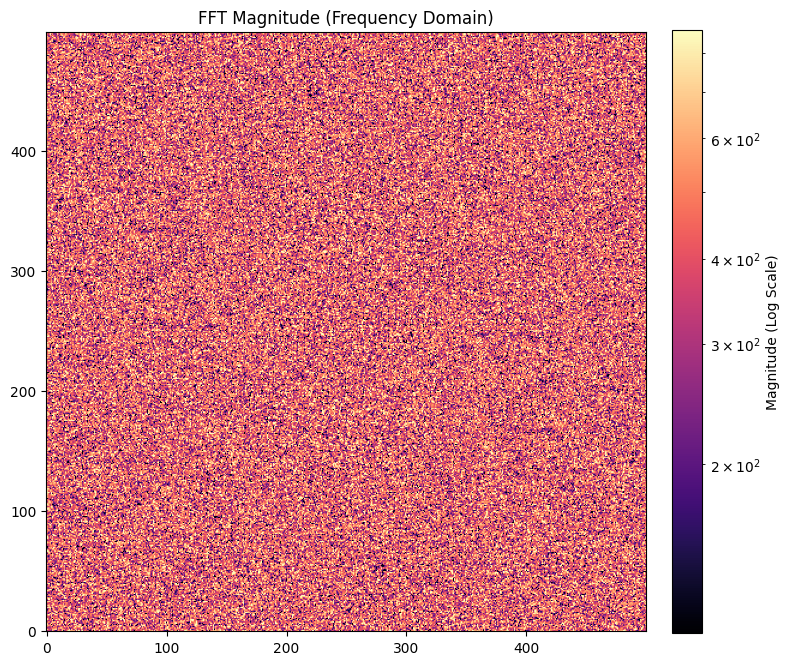

In [8]:
###########AI-Generated###############
from scipy.fftpack import fftn, fftshift
noise_fft = fftn(gaussian_noise)
noise_fft_shifted = fftshift(noise_fft)
magnitude_spectrum = np.abs(noise_fft_shifted)

plt.figure(figsize=(8, 8))
plt.imshow(magnitude_spectrum, cmap='magma', origin='lower', 
                 norm=colors.LogNorm(vmin=np.percentile(magnitude_spectrum, 5), 
                                     vmax=np.percentile(magnitude_spectrum, 95)))
plt.title('FFT Magnitude (Frequency Domain)')
plt.colorbar(label='Magnitude (Log Scale)', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


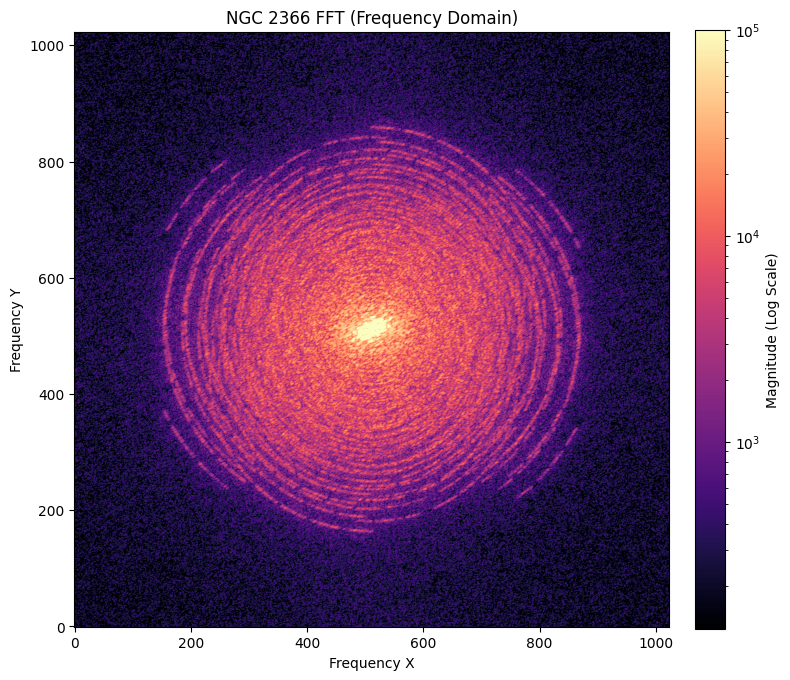

In [9]:
###########AI-Generated###############
galaxy_fft = fftn(image_data_2d)
galaxy_fft_shifted = fftshift(galaxy_fft)

magnitude_spectrum = np.abs(galaxy_fft_shifted)

plt.figure(figsize=(8, 8))

plt.imshow(magnitude_spectrum, cmap='magma', origin='lower',  #afmhot
           norm=colors.LogNorm(vmin=np.percentile(magnitude_spectrum, 10), 
                               vmax=np.percentile(magnitude_spectrum, 99.9)))

plt.title('NGC 2366 FFT (Frequency Domain)')
plt.xlabel('Frequency X')
plt.ylabel('Frequency Y')
plt.colorbar(label='Magnitude (Log Scale)', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

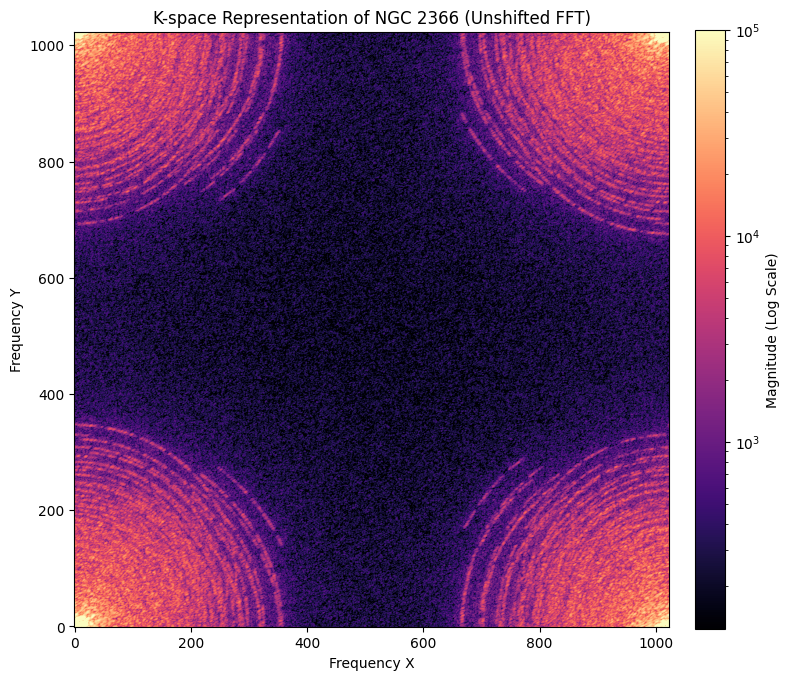

In [10]:
###########AI-Generated###############
galaxy_fft = fftn(image_data_2d)

magnitude_spectrum = np.abs(galaxy_fft)

plt.figure(figsize=(8, 8))

plt.imshow(magnitude_spectrum, cmap='magma', origin='lower', 
           norm=colors.LogNorm(vmin=np.percentile(magnitude_spectrum, 10), 
                               vmax=np.percentile(magnitude_spectrum, 99.9)))

plt.title('K-space Representation of NGC 2366 (Unshifted FFT)')
plt.xlabel('Frequency X')
plt.ylabel('Frequency Y')
plt.colorbar(label='Magnitude (Log Scale)', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

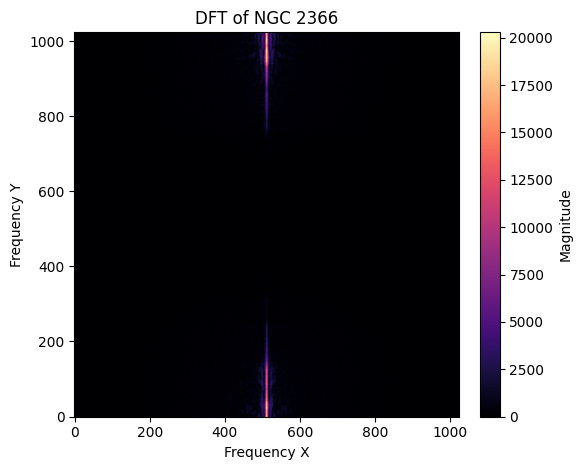

In [15]:
galaxy_dft = np.fft.fft(image_data_2d)
magnitude_spectrum = fftshift(np.abs(galaxy_dft))

plt.figure()
plt.imshow(magnitude_spectrum, cmap='magma', origin='lower')
plt.title('DFT of NGC 2366')
plt.xlabel('Frequency X')
plt.ylabel('Frequency Y')
plt.colorbar(label='Magnitude', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()